# TensorRT vs PyTorch 特征提取对比测试

对比检查 TRT FP16 engine 和 PyTorch 模型在相同输入上的特征输出差异。

In [1]:
import sys, os
import pyrootutils
root = pyrootutils.setup_root(
    search_from=os.getcwd(),
    indicator=["__root__.txt"],
    pythonpath=True,
    dotenv=True,
)
sys.path.append(str(root))

import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

np.bool = np.bool_
torch.set_grad_enabled(False)
print(f"root: {root}")
print(f"CUDA: {torch.cuda.is_available()}, device: {torch.cuda.get_device_name(0)}")

root: /root/zhaokj/CVLface_rec/cvlface
CUDA: True, device: NVIDIA GeForce RTX 4090


In [3]:
# === 配置 ===
CKPT_PATH = "/data2/dataset_0605/train_output/s2_body36_0605_06-10_2/checkpoints_every_epoch/epoch:0_step:9053"
IMAGE_DIR = "/data1/dataset_0605/try"
BATCH_SIZE = 64
MAX_IMAGES = 10000  # 测试图片数量上限


In [4]:
# === 加载 PyTorch 模型 ===
from models import get_model
from general_utils.config_utils import load_config

model_config = load_config(os.path.join(CKPT_PATH, "model.yaml"))
model_config.start_from = ""
model_config.freeze = False
model = get_model(model_config, "work_0605")
model.load_state_dict_from_path(os.path.join(CKPT_PATH, "model.pt"))
model.eval().cuda()
print(f"模型加载完成: {type(model).__name__}")

Loaded iResNet model
compatible keys in state_dict 917 / 917
Check


<All keys matched successfully>
Loaded pretrained model from /data2/dataset_0605/train_output/s2_body36_0605_06-10_2/checkpoints_every_epoch/epoch:0_step:9053/model.pt
模型加载完成: IResNetModel


In [5]:
# === 构建 TRT engine (FP16) ===
import tensorrt as trt

def build_trt_engine(model, batch_size, cache_dir="/tmp/trt_test_cache"):
    os.makedirs(cache_dir, exist_ok=True)
    onnx_path = os.path.join(cache_dir, "model.onnx")
    engine_path = os.path.join(cache_dir, "model.engine")

    model_fp16 = model.half().cuda()
    model_fp16.eval()
    dummy = torch.randn(batch_size, 3, 112, 112, device="cuda", dtype=torch.float16)
    torch.onnx.export(model_fp16, dummy, onnx_path,
                      input_names=["input"], output_names=["output"],
                      opset_version=17, dynamo=False)
    print(f"ONNX 导出完成: {onnx_path}")

    logger = trt.Logger(trt.Logger.WARNING)
    builder = trt.Builder(logger)
    network = builder.create_network()
    parser = trt.OnnxParser(network, logger)
    with open(onnx_path, "rb") as f:
        if not parser.parse(f.read()):
            for i in range(parser.num_errors):
                print(f"TRT Error: {parser.get_error(i)}")
            raise RuntimeError("TRT parse failed")

    config = builder.create_builder_config()
    config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 4 << 30)
    # 注意: 这里没有显式设 FP16 flag, 和 eval_all_trt_single.py 一致
    serialized = builder.build_serialized_network(network, config)
    with open(engine_path, "wb") as f:
        f.write(serialized)
    os.remove(onnx_path)
    print(f"TRT engine 构建完成: {engine_path}")
    return engine_path

engine_path = build_trt_engine(model, BATCH_SIZE)
# 模型转回 float32 用于 torch 推理对比
model = model.float().cuda()

/tmp/ipykernel_3890739/3607785718.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model_fp16, dummy, onnx_path,


ONNX 导出完成: /tmp/trt_test_cache/model.onnx
TRT engine 构建完成: /tmp/trt_test_cache/model.engine


In [6]:
# === TRT 推理器 (和 eval_all_trt_single.py 中完全一致) ===
class TRTInfer:
    def __init__(self, engine_path, batch_size=256):
        logger = trt.Logger(trt.Logger.WARNING)
        runtime = trt.Runtime(logger)
        with open(engine_path, "rb") as f:
            self.engine = runtime.deserialize_cuda_engine(memoryview(f.read()))
        self.context = self.engine.create_execution_context()
        self.input_name = self.engine.get_tensor_name(0)
        self.output_name = self.engine.get_tensor_name(1)
        self.batch_size = batch_size
        self.d_input = torch.zeros(batch_size, 3, 112, 112, dtype=torch.float16, device="cuda")
        self.d_output = torch.zeros(batch_size, 512, dtype=torch.float16, device="cuda")
        self.context.set_tensor_address(self.input_name, self.d_input.data_ptr())
        self.context.set_tensor_address(self.output_name, self.d_output.data_ptr())
        self.stream = torch.cuda.Stream()

    def __call__(self, x):
        total = x.shape[0]
        x_fp16 = x.half()
        if total <= self.batch_size:
            self.d_input[:total].copy_(x_fp16)
            self.context.execute_async_v3(self.stream.cuda_stream)
            self.stream.synchronize()
            return self.d_output[:total].float()
        results = []
        for s in range(0, total, self.batch_size):
            e = min(s + self.batch_size, total)
            bs = e - s
            self.d_input[:bs].copy_(x_fp16[s:e])
            self.context.execute_async_v3(self.stream.cuda_stream)
            self.stream.synchronize()
            results.append(self.d_output[:bs].float().clone())
        return torch.cat(results, dim=0)

trt_infer = TRTInfer(engine_path, batch_size=BATCH_SIZE)
print("TRT 推理器就绪")

TRT 推理器就绪


In [7]:
# === 加载测试图片 ===
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

image_paths = []
for person_dir in sorted(os.listdir(IMAGE_DIR))[:50]:  # 取前50个人
    person_path = os.path.join(IMAGE_DIR, person_dir)
    if not os.path.isdir(person_path):
        continue
    for img_name in sorted(os.listdir(person_path)):
        if img_name.endswith(".jpg"):
            image_paths.append(os.path.join(person_path, img_name))
        if len(image_paths) >= MAX_IMAGES:
            break
    if len(image_paths) >= MAX_IMAGES:
        break

print(f"加载 {len(image_paths)} 张图片")

# 预处理
images = []
for p in tqdm(image_paths, desc="读取图片"):
    img = Image.open(p).convert("RGB")
    images.append(transform(img))

image_tensor = torch.stack(images).cuda()
print(f"输入 tensor: {image_tensor.shape}, dtype={image_tensor.dtype}")
print(f"值范围: [{image_tensor.min():.3f}, {image_tensor.max():.3f}]")

加载 2424 张图片


读取图片: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 2424/2424 [00:01<00:00, 1512.72it/s]


输入 tensor: torch.Size([2424, 3, 112, 112]), dtype=torch.float32
值范围: [-1.000, 1.000]


In [8]:
# === 对比推理 ===
# PyTorch FP32 推理
torch_feats = []
for i in range(0, len(image_tensor), BATCH_SIZE):
    batch = image_tensor[i:i+BATCH_SIZE]
    with torch.no_grad():
        feat = model(batch)
    torch_feats.append(feat.cpu())
torch_feats = torch.cat(torch_feats, dim=0)

# PyTorch FP16 推理 (对照组)
model_fp16 = model.half()
torch_fp16_feats = []
for i in range(0, len(image_tensor), BATCH_SIZE):
    batch = image_tensor[i:i+BATCH_SIZE].half()
    with torch.no_grad():
        feat = model_fp16(batch)
    torch_fp16_feats.append(feat.float().cpu())
torch_fp16_feats = torch.cat(torch_fp16_feats, dim=0)
model = model.float()  # 恢复

# TRT FP16 推理
trt_feats = []
for i in range(0, len(image_tensor), BATCH_SIZE):
    batch = image_tensor[i:i+BATCH_SIZE]
    feat = trt_infer(batch)
    trt_feats.append(feat.cpu())
trt_feats = torch.cat(trt_feats, dim=0)

print(f"Torch FP32 特征: {torch_feats.shape}")
print(f"Torch FP16 特征: {torch_fp16_feats.shape}")
print(f"TRT FP16 特征:   {trt_feats.shape}")

Torch FP32 特征: torch.Size([2424, 512])
Torch FP16 特征: torch.Size([2424, 512])
TRT FP16 特征:   torch.Size([2424, 512])


In [10]:
# === 数值对比 ===
# L2 归一化后比较 (和评估流程一致)
torch_norm = F.normalize(torch_feats, dim=1)
torch_fp16_norm = F.normalize(torch_fp16_feats, dim=1)
trt_norm = F.normalize(trt_feats, dim=1)

# 余弦相似度
cos_trt_vs_fp32 = F.cosine_similarity(torch_norm, trt_norm, dim=1)
cos_trt_vs_fp16 = F.cosine_similarity(torch_fp16_norm, trt_norm, dim=1)
cos_fp16_vs_fp32 = F.cosine_similarity(torch_norm, torch_fp16_norm, dim=1)

print("=" * 60)
print("余弦相似度统计 (越接近1越好):")
print("=" * 60)
print(f"TRT vs Torch FP32:  mean={cos_trt_vs_fp32.mean():.6f}, min={cos_trt_vs_fp32.min():.6f}, std={cos_trt_vs_fp32.std():.6f}")
print(f"TRT vs Torch FP16:  mean={cos_trt_vs_fp16.mean():.6f}, min={cos_trt_vs_fp16.min():.6f}, std={cos_trt_vs_fp16.std():.6f}")
print(f"FP16 vs FP32:       mean={cos_fp16_vs_fp32.mean():.6f}, min={cos_fp16_vs_fp32.min():.6f}, std={cos_fp16_vs_fp32.std():.6f}")

# 绝对误差
abs_err_trt = (trt_feats - torch_feats).abs()
abs_err_fp16 = (torch_fp16_feats - torch_feats).abs()
print(f"绝对误差 (未归一化):")
print(f"TRT vs FP32:  mean={abs_err_trt.mean():.6f}, max={abs_err_trt.max():.6f}")
print(f"FP16 vs FP32: mean={abs_err_fp16.mean():.6f}, max={abs_err_fp16.max():.6f}")

余弦相似度统计 (越接近1越好):
TRT vs Torch FP32:  mean=0.999967, min=0.999774, std=0.000011
TRT vs Torch FP16:  mean=0.999966, min=0.999763, std=0.000012
FP16 vs FP32:       mean=0.999998, min=0.999981, std=0.000001
绝对误差 (未归一化):
TRT vs FP32:  mean=0.005339, max=0.042471
FP16 vs FP32: mean=0.001249, max=0.015194


In [12]:
# === 检查异常值 ===
print("NaN 检查:")
print(f"  Torch FP32: {torch_feats.isnan().any().item()}")
print(f"  Torch FP16: {torch_fp16_feats.isnan().any().item()}")
print(f"  TRT FP16:   {trt_feats.isnan().any().item()}")
print(f"Inf 检查:")
print(f"  Torch FP32: {torch_feats.isinf().any().item()}")
print(f"  Torch FP16: {torch_fp16_feats.isinf().any().item()}")
print(f"  TRT FP16:   {trt_feats.isinf().any().item()}")

# 特征 norm 分布
torch_norms = torch_feats.norm(dim=1)
trt_norms = trt_feats.norm(dim=1)
fp16_norms = torch_fp16_feats.norm(dim=1)
print(f"特征 L2 Norm:")
print(f"  Torch FP32: mean={torch_norms.mean():.4f}, std={torch_norms.std():.4f}, min={torch_norms.min():.4f}, max={torch_norms.max():.4f}")
print(f"  Torch FP16: mean={fp16_norms.mean():.4f}, std={fp16_norms.std():.4f}, min={fp16_norms.min():.4f}, max={fp16_norms.max():.4f}")
print(f"  TRT FP16:   mean={trt_norms.mean():.4f}, std={trt_norms.std():.4f}, min={trt_norms.min():.4f}, max={trt_norms.max():.4f}")

NaN 检查:
  Torch FP32: False
  Torch FP16: False
  TRT FP16:   False
Inf 检查:
  Torch FP32: False
  Torch FP16: False
  TRT FP16:   False
特征 L2 Norm:
  Torch FP32: mean=18.8854, std=2.2094, min=10.7726, max=25.1531
  Torch FP16: mean=18.8856, std=2.2094, min=10.7800, max=25.1542
  TRT FP16:   mean=18.8881, std=2.2092, min=10.7658, max=25.1661


In [13]:
# === 模拟 verification: 同一人 vs 不同人的 pair 对比 ===
import sklearn.preprocessing

def compute_pair_accuracy(feats, image_paths, top_n=100):
    """用前 top_n 张图测试: 同人 pair cos > 不同人 pair cos 的比率"""
    feats_np = sklearn.preprocessing.normalize(feats[:top_n].numpy())

    # 从路径提取 label (目录名)
    labels = [os.path.basename(os.path.dirname(p)) for p in image_paths[:top_n]]
    unique_labels = list(set(labels))

    same_scores = []
    diff_scores = []
    for i in range(top_n):
        for j in range(i+1, top_n):
            score = np.dot(feats_np[i], feats_np[j])
            if labels[i] == labels[j]:
                same_scores.append(score)
            else:
                diff_scores.append(score)

    same_scores = np.array(same_scores)
    diff_scores = np.array(diff_scores)

    # 简单阈值: 同人均值和不同人均值的中点
    if len(same_scores) > 0 and len(diff_scores) > 0:
        threshold = (same_scores.mean() + diff_scores.mean()) / 2
        tp = (same_scores > threshold).sum()
        tn = (diff_scores <= threshold).sum()
        acc = (tp + tn) / (len(same_scores) + len(diff_scores))
        return acc, same_scores.mean(), diff_scores.mean(), threshold
    return None, None, None, None

print("=" * 60)
print("Pair Verification 对比 (前100张图):")
print("=" * 60)

for name, feats in [("Torch FP32", torch_feats), ("Torch FP16", torch_fp16_feats), ("TRT FP16", trt_feats)]:
    acc, same_mean, diff_mean, thr = compute_pair_accuracy(feats, image_paths)
    if acc is not None:
        print(f"{name:12s}: acc={acc:.4f}, same_mean={same_mean:.4f}, diff_mean={diff_mean:.4f}, threshold={thr:.4f}")
    else:
        print(f"{name:12s}: 样本不足")

Pair Verification 对比 (前100张图):
Torch FP32  : acc=0.9879, same_mean=0.4740, diff_mean=0.0030, threshold=0.2385
Torch FP16  : acc=0.9879, same_mean=0.4740, diff_mean=0.0030, threshold=0.2385
TRT FP16    : acc=0.9879, same_mean=0.4739, diff_mean=0.0030, threshold=0.2384


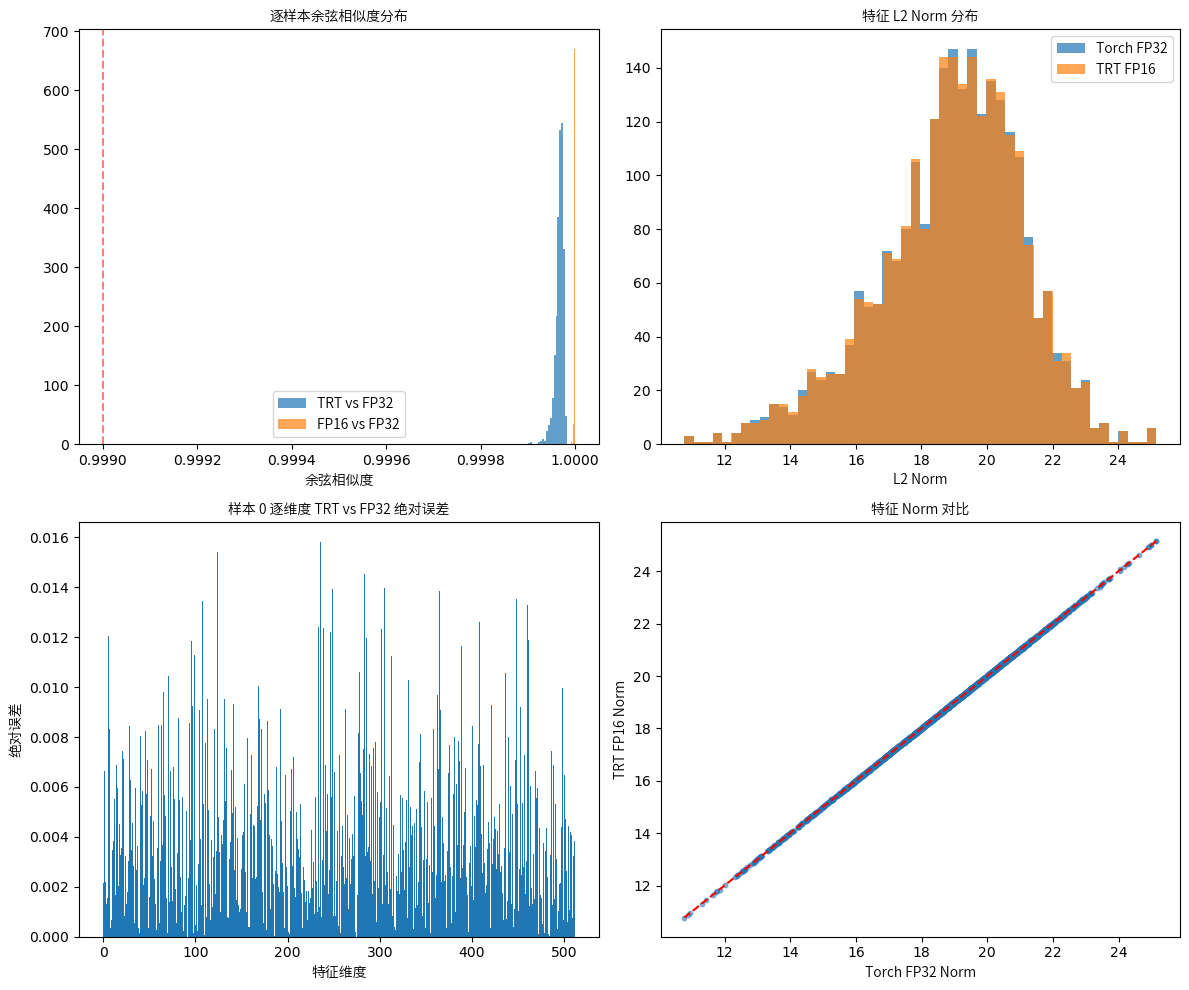

图片已保存: trt_vs_torch_comparison.png


In [14]:
# === 可视化 ===
from matplotlib.font_manager import FontProperties
font = FontProperties(fname="/root/zhaokj/font/SourceHanSansSC-Normal.otf")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 余弦相似度分布
axes[0, 0].hist(cos_trt_vs_fp32.numpy(), bins=50, alpha=0.7, label="TRT vs FP32")
axes[0, 0].hist(cos_fp16_vs_fp32.numpy(), bins=50, alpha=0.7, label="FP16 vs FP32")
axes[0, 0].set_xlabel("余弦相似度", fontproperties=font)
axes[0, 0].set_title("逐样本余弦相似度分布", fontproperties=font)
axes[0, 0].legend(prop=font)
axes[0, 0].axvline(x=0.999, color="r", linestyle="--", alpha=0.5)

# 2. L2 Norm 分布
axes[0, 1].hist(torch_norms.numpy(), bins=50, alpha=0.7, label="Torch FP32")
axes[0, 1].hist(trt_norms.numpy(), bins=50, alpha=0.7, label="TRT FP16")
axes[0, 1].set_xlabel("L2 Norm", fontproperties=font)
axes[0, 1].set_title("特征 L2 Norm 分布", fontproperties=font)
axes[0, 1].legend(prop=font)

# 3. 逐维度误差 (随机选一个样本)
sample_idx = 0
dim_err = (trt_feats[sample_idx] - torch_feats[sample_idx]).abs().numpy()
axes[1, 0].bar(range(len(dim_err)), dim_err, width=1.0)
axes[1, 0].set_xlabel("特征维度", fontproperties=font)
axes[1, 0].set_ylabel("绝对误差", fontproperties=font)
axes[1, 0].set_title(f"样本 {sample_idx} 逐维度 TRT vs FP32 绝对误差", fontproperties=font)

# 4. 散点图: TRT norm vs Torch norm
axes[1, 1].scatter(torch_norms.numpy(), trt_norms.numpy(), alpha=0.5, s=10)
axes[1, 1].plot([torch_norms.min(), torch_norms.max()],
               [torch_norms.min(), torch_norms.max()], "r--")
axes[1, 1].set_xlabel("Torch FP32 Norm", fontproperties=font)
axes[1, 1].set_ylabel("TRT FP16 Norm", fontproperties=font)
axes[1, 1].set_title("特征 Norm 对比", fontproperties=font)

plt.tight_layout()
plt.savefig("trt_vs_torch_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("图片已保存: trt_vs_torch_comparison.png")

## 关键排查点

如果 TRT 和 Torch 余弦相似度很高 (>0.999) 但评估结果差异大，问题可能在:
1. **数据预处理差异**: TRT single 中的 transform 和 torch evaluator 中不一致
2. **flip 特征合并方式**:  vs 
3. **L2 归一化时机**: 评估指标计算前是否都做了 normalize
4. **batch size 不足**: TRT 的 d_input/d_output 预分配了固定 batch_size，最后一个 batch 是否有残留数据

如果余弦相似度很低 (<0.99)，问题在 TRT 转换本身:
1. **FP16 精度溢出**: 某些层在 FP16 下数值不稳定
2. **ONNX 导出 bug**: opset 版本或算子不兼容
3. **input shape 不匹配**: engine 构建时的 batch_size 和推理时不一致
